In [92]:
pip install -U datasets


In [93]:
from datasets import load_dataset, DatasetDict, Dataset
import pandas as pd
import ast, time
from tqdm import tqdm

In [94]:
from huggingface_hub import login
import google.colab.auth
from google.colab import userdata

hf_token = userdata.get("distil_gpt_token")
login(hf_token)

#load data

In [95]:
from datasets import load_dataset

data_sample = load_dataset("QuyenAnhDE/Diseases_Symptoms")
print(data_sample)

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['Code', 'Name', 'Symptoms', 'Treatments'],
        num_rows: 400
    })
})


In [96]:
data_sample

DatasetDict({
    train: Dataset({
        features: ['Code', 'Name', 'Symptoms', 'Treatments'],
        num_rows: 400
    })
})

In [97]:
updatated_data = [{'Name': item["Name"], 'Symptoms': item["Symptoms"], 'Treatments': item["Treatments"]} for item in data_sample['train']]

In [98]:
df =pd.DataFrame(updatated_data)

In [99]:
df

,Name,Symptoms,Treatments
0,Panic disorder,"Palpitations, Sweating, Trembling, Shortness o...","Antidepressant medications, Cognitive Behavior..."
1,Vocal cord polyp,"Hoarseness, Vocal Changes, Vocal Fatigue","Voice Rest, Speech Therapy, Surgical Removal"
2,Turner syndrome,"Short stature, Gonadal dysgenesis, Webbed neck...","Growth hormone therapy, Estrogen replacement t..."
3,Cryptorchidism,"Absence or undescended testicle(s), empty scro...",Observation and monitoring (in cases of mild o...
4,Ethylene glycol poisoning-1,"Nausea, vomiting, abdominal pain, General mala...","Supportive Measures, Gastric Decontamination, ..."
...,...,...,...
395,Urinary Stones (Kidney Stones),"Severe abdominal or back pain, blood in urine,...","Pain management, increased fluid intake, medic..."
396,Osteoporosis,"Fragile bones, loss of height over time, back ...","Calcium and vitamin D supplements, regular exe..."
397,Rheumatoid Arthritis,"Joint pain, stiffness, swelling, fatigue, loss...",Medications (nonsteroidal anti-inflammatory dr...
398,Type 1 Diabetes,"Frequent urination, Increased thirst, Weight loss","Insulin therapy, Blood sugar monitoring, Healt..."


#extracting symptoms and treatments

In [100]:
df['Symptoms'] = df['Symptoms'].apply(lambda x: ', '.join(s.strip() for s in x.split(',')) if isinstance(x, str) else '')
df['Treatments'] = df['Treatments'].apply(lambda x: ', '.join(s.strip() for s in x.split(',')) if isinstance(x, str) else '')


In [101]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch.nn as nn
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

In [102]:
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

In [103]:
tokenizer = GPT2Tokenizer.from_pretrained('distilgpt2')
model = GPT2LMHeadModel.from_pretrained('distilgpt2').to(device)

In [104]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        400 non-null    object
 1   Symptoms    400 non-null    object
 2   Treatments  400 non-null    object
dtypes: object(3)
memory usage: 9.5+ KB


In [106]:
df.drop_duplicates()

,Name,Symptoms,Treatments
0,Panic disorder,"Palpitations, Sweating, Trembling, Shortness o...","Antidepressant medications, Cognitive Behavior..."
1,Vocal cord polyp,"Hoarseness, Vocal Changes, Vocal Fatigue","Voice Rest, Speech Therapy, Surgical Removal"
2,Turner syndrome,"Short stature, Gonadal dysgenesis, Webbed neck...","Growth hormone therapy, Estrogen replacement t..."
3,Cryptorchidism,"Absence or undescended testicle(s), empty scro...",Observation and monitoring (in cases of mild o...
4,Ethylene glycol poisoning-1,"Nausea, vomiting, abdominal pain, General mala...","Supportive Measures, Gastric Decontamination, ..."
...,...,...,...
395,Urinary Stones (Kidney Stones),"Severe abdominal or back pain, blood in urine,...","Pain management, increased fluid intake, medic..."
396,Osteoporosis,"Fragile bones, loss of height over time, back ...","Calcium and vitamin D supplements, regular exe..."
397,Rheumatoid Arthritis,"Joint pain, stiffness, swelling, fatigue, loss...",Medications (nonsteroidal anti-inflammatory dr...
398,Type 1 Diabetes,"Frequent urination, Increased thirst, Weight loss","Insulin therapy, Blood sugar monitoring, Healt..."


In [107]:
df.describe()

,Name,Symptoms,Treatments
count,400,400,400
unique,392,395,387
top,Sciatica,"Swelling, pain, dry mouth, bad taste","Hydration, Saliva stimulation, Stone removal"
freq,3,3,4


In [108]:
BATCH_SIZE = 8

# dataset preparation

In [109]:
class LanguageData(Dataset):
  def __init__(self, df, tokenizer):
    self.labels = df.columns
    self.data = df.to_dict(orient='records')
    self.tokenizer = tokenizer
    x = self.fittest_max_length(df)
    self.max_len = x

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    x = self.data[idx][self.labels[0]]
    y = self.data[idx][self.labels[1]]
    text = f"{x} | {y}"
    tokens = self.tokenizer.encode_plus(text, return_tensors= 'pt', max_length = 128, padding='max_length', truncation=True)
    return tokens

  # for calculating maximum seq length needed for padding in df and find smallest power of 2
  def fittest_max_length(self,df):
    max_length = max(len(max(df[self.labels[0]], key=len)), len(max(df[self.labels[1]], key = len )))
    x = 2
    while x < max_length: x = x*2
    return x


In [110]:
dataset_sample = LanguageData(df, tokenizer)

In [111]:
data_sample

DatasetDict({
    train: Dataset({
        features: ['Code', 'Name', 'Symptoms', 'Treatments'],
        num_rows: 400
    })
})

In [112]:
len(dataset_sample)

400

In [113]:
train_size = int(0.8 * len(dataset_sample))

In [114]:
val_size = len(dataset_sample) - train_size
print(val_size)

80


In [115]:
train_data, val_data  = random_split(dataset_sample, [train_size, val_size])

In [116]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

In [117]:
num_epochs = 7

In [118]:
batch_size = BATCH_SIZE
model_name = 'distilgpt2'
gpu = 0

In [119]:
loss_fn = nn.CrossEntropyLoss(ignore_index = tokenizer.pad_token_id)
optimizer = optim.Adam(model.parameters(), lr=2e-4)
tokenizer.pad_token = tokenizer.eos_token


In [120]:
results = pd.DataFrame(columns= ['epoch', 'batch_size', 'transformers', 'gpu','training_loss','validation_loss','epoch_duration'])

In [121]:
from tqdm import tqdm

In [122]:
# import wandb
# wandb.login()
# wandb.init(project="distilGPT-finetuned", config ={
#     "epoch":num_epochs,
#     "batch_size":BATCH_SIZE,
#     "learning_rate":2e-4,
#     "model":model_name,
#     "gpu":gpu
# })

In [123]:
for epoch in range(num_epochs):
  start_time = time.time()

  model.train()
  training_loss = 0
  train_iterator = tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{num_epochs} Batch size : {batch_size} Model : {model_name} GPU : {gpu}")

  for step,batch in enumerate(train_iterator):
    optimizer.zero_grad()

    inputs = batch['input_ids'].squeeze(1).to(device)
    targets = inputs.clone()

    outputs = model(inputs, labels=targets)
    loss = outputs.loss
    loss.backward()
    optimizer.step()

    training_loss += loss.item()
    train_iterator.set_postfix(loss =loss.item())

    # wandb.log({
    #         "train/batch_loss": loss.item(),
    #         "epoch": epoch+1,
    #         "step": step
    #     })


  avg_training_loss = training_loss / len(train_iterator)

  model.eval()
  val_loss = 0
  total_loss = 0
  val_iterator = tqdm(val_loader, desc=f"Validation epoch {epoch+1}/{num_epochs}")

  with torch.no_grad():
    for batch in val_iterator:
      inputs = batch['input_ids'].squeeze(1).to(device)
      targets = inputs.clone()

      outputs = model(inputs, labels=targets)
      loss = outputs.loss
      val_iterator.set_postfix(loss = loss.item())
      val_loss += loss.item()

  avg_val_loss = val_loss / len(val_iterator)

end_time = time.time()
epoch_duration_time = end_time -start_time

# log epoch metrics
# wandb.log({
#       "train/epoch_loss": avg_training_loss,
#       "val/epoch_loss": avg_val_loss,
#       "epoch_time": epoch_duration_time,
#       "epoch": epoch+1
# })

new_row = {'epoch': epoch+1,
           'batch_size': batch_size,
           'transformers': model_name,
           'gpu': gpu,
           'training_loss': avg_training_loss,
           'validation_loss': avg_val_loss,
           'epoch_duration': epoch_duration_time
          }

results.loc[len(results)] = new_row

print(f"Epoch: {epoch+1}, Training Loss: {avg_training_loss:.4f} ,Validation Loss: {total_loss/ len(val_loader)}, Time: {epoch_duration_time:.2f}s")

Training Epoch 1/7 Batch size : 8 Model : distilgpt2 GPU : 0: 100%|██████████| 40/40 [00:08<00:00,  4.78it/s, loss=0.722]
Validation epoch 1/7: 100%|██████████| 10/10 [00:00<00:00, 15.91it/s, loss=0.598]
Training Epoch 2/7 Batch size : 8 Model : distilgpt2 GPU : 0: 100%|██████████| 40/40 [00:08<00:00,  4.71it/s, loss=0.671]
Validation epoch 2/7: 100%|██████████| 10/10 [00:00<00:00, 16.45it/s, loss=0.527]
Training Epoch 3/7 Batch size : 8 Model : distilgpt2 GPU : 0: 100%|██████████| 40/40 [00:08<00:00,  4.64it/s, loss=0.399]
Validation epoch 3/7: 100%|██████████| 10/10 [00:00<00:00, 16.26it/s, loss=0.529]
Training Epoch 4/7 Batch size : 8 Model : distilgpt2 GPU : 0: 100%|██████████| 40/40 [00:08<00:00,  4.65it/s, loss=0.442]
Validation epoch 4/7: 100%|██████████| 10/10 [00:00<00:00, 14.82it/s, loss=0.536]
Training Epoch 5/7 Batch size : 8 Model : distilgpt2 GPU : 0: 100%|██████████| 40/40 [00:08<00:00,  4.88it/s, loss=0.379]
Validation epoch 5/7: 100%|██████████| 10/10 [00:00<00:00, 17.

Epoch: 7, Training Loss: 0.2406 ,Validation Loss: 0.0, Time: 8.32s


In [124]:
input_Str = "heart attack"

In [126]:
input_ids = tokenizer.encode(input_Str, return_tensors='pt').to(device)

In [127]:
input_ids

tensor([[11499,  1368]], device='cuda:0')

In [128]:
output = model.generate(
    input_ids,
    max_length =20,
    num_return_sequences = 1,
    do_sample=True,
    top_k=8,
    top_p=0.95,
    temperature=0.3,
    repetition_penalty= 1.2
)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [129]:
output

tensor([[11499,  1368,   930, 25544,  2356,    11, 29844,    11,  2266,  1108,
            11, 35519,  1108,   393,  3833,   287,   262,  1021,   290,  9353]],
       device='cuda:0')

In [130]:
decoded_output = tokenizer.decode(output[0], skip_special_tokens=True)

In [131]:
decoded_output

'heart attack | Chest pain, swelling, redness, numbness or pressure in the hand and fingers'

In [132]:
input_str2 = "lung-infection"
input_ids2 = tokenizer.encode(input_str2, return_tensors='pt').to(device)


In [133]:
output = model.generate(
    input_ids2,
    max_length =20,
    num_return_sequences = 1,
    do_sample=True,
    top_k=8,
    top_p=0.95,
    temperature=0.3,
    repetition_penalty= 1.2,
    pad_token_id=tokenizer.eos_token_id
)

In [134]:
decoded_output2 = tokenizer.decode(output[0], skip_special_tokens=True)
print(decoded_output2)

lung-infection | Painless swelling, redness, numbness, limited range of motion


In [135]:
df

,Name,Symptoms,Treatments
0,Panic disorder,"Palpitations, Sweating, Trembling, Shortness o...","Antidepressant medications, Cognitive Behavior..."
1,Vocal cord polyp,"Hoarseness, Vocal Changes, Vocal Fatigue","Voice Rest, Speech Therapy, Surgical Removal"
2,Turner syndrome,"Short stature, Gonadal dysgenesis, Webbed neck...","Growth hormone therapy, Estrogen replacement t..."
3,Cryptorchidism,"Absence or undescended testicle(s), empty scro...",Observation and monitoring (in cases of mild o...
4,Ethylene glycol poisoning-1,"Nausea, vomiting, abdominal pain, General mala...","Supportive Measures, Gastric Decontamination, ..."
...,...,...,...
395,Urinary Stones (Kidney Stones),"Severe abdominal or back pain, blood in urine,...","Pain management, increased fluid intake, medic..."
396,Osteoporosis,"Fragile bones, loss of height over time, back ...","Calcium and vitamin D supplements, regular exe..."
397,Rheumatoid Arthritis,"Joint pain, stiffness, swelling, fatigue, loss...",Medications (nonsteroidal anti-inflammatory dr...
398,Type 1 Diabetes,"Frequent urination, Increased thirst, Weight loss","Insulin therapy, Blood sugar monitoring, Healt..."


In [136]:
input_str3 = 'Type 1 Diabetes'
input_ids3 = tokenizer.encode(input_str3, return_tensors='pt').to(device)

In [137]:
output = model.generate(
    input_ids3,
    max_length =20,
    num_return_sequences = 3,
    do_sample=True,
    top_k=8,
    top_p=0.95,
    temperature=0.3,
    repetition_penalty= 1.2
)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [138]:
decoded_output4 = tokenizer.decode(output[0], skip_special_tokens=True)
print(decoded_output4)

Type 1 Diabetes | Frequent episodes of binge eating followed by decreased appetite, increased thirst, reduced exercise


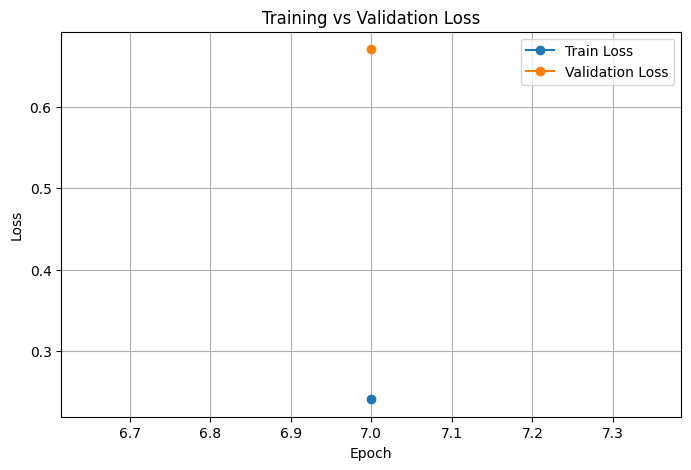

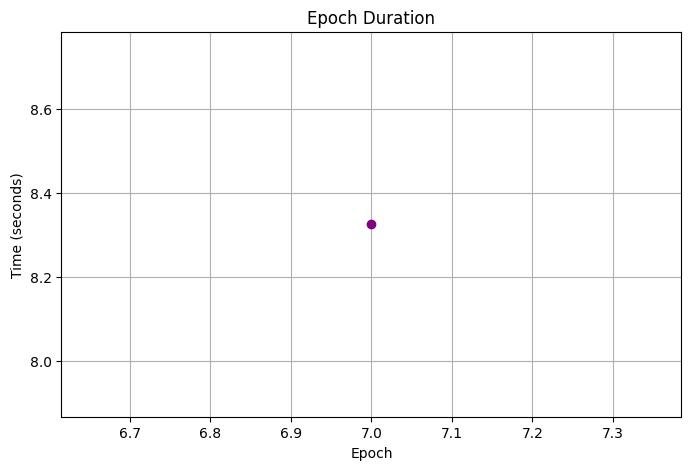

In [140]:
import matplotlib.pyplot as plt

# Plot Loss Curves
plt.figure(figsize=(8,5))
plt.plot(results["epoch"], results["training_loss"], marker="o", label="Train Loss")
plt.plot(results["epoch"], results["validation_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot Epoch Duration
plt.figure(figsize=(8,5))
plt.plot(results["epoch"], results["epoch_duration"], marker="o", color="purple")
plt.xlabel("Epoch")
plt.ylabel("Time (seconds)")
plt.title("Epoch Duration")
plt.grid(True)
plt.show()
